In [1]:
import sqlite3

def update_experiment_view(db_path='../cem_results.db'):
    """
    Drops the existing experiment_summary view and recreates it 
    with the updated metrics schema including the testset column.
    """
    # Define the SQL script
    sql_script = """
    DROP VIEW IF EXISTS experiment_summary;

    CREATE VIEW experiment_summary AS
    SELECT 
        r.dataset,
        r.entity, 
        r.train_size, 
        r.seed, 
        r.lm,
        m.pollution, 
        m.iteration, 
        m.testset,
        m.f1_score,
        m.precision,
        m.recall,
        m.is_final,
        r.run_id
    FROM metrics m
    JOIN runs r ON m.run_id = r.run_id;
    """

    try:
        # Establish connection
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        
        # Execute the script (handles multiple statements)
        cursor.executescript(sql_script)
        
        conn.commit()
        print("View 'experiment_summary' has been updated successfully.")
        
    except sqlite3.Error as e:
        print(f"An error occurred: {e}")
        
    finally:
        if conn:
            conn.close()

# Run the update


In [19]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connection
conn = sqlite3.connect('../cem_results.db')
update_experiment_view()
i = 8 # Set your desired number of recent runs here

try:
    # 2. Query the last 'i' run_ids from the "runs" table
    # We order by timestamp to ensure we get the truly most recent runs
    id_query = f"""SELECT r.run_id FROM runs r
    WHERE EXISTS (
    SELECT 1 FROM metrics m 
    WHERE m.run_id = r.run_id
    AND m.is_final = 1 
    AND m.testset = 'conv'
    )
    ORDER BY r.timestamp DESC LIMIT {i}"""
    last_run_ids = pd.read_sql_query(id_query, conn)['run_id'].tolist()
    
    if not last_run_ids:
        print("No runs found in the database.")
    else:
        print(last_run_ids)
        # 3. Query experiment_summary for these IDs where is_final=1
        # Using placeholders to prevent SQL injection and handle the list safely
        placeholders = ', '.join(['?'] * len(last_run_ids))
        summary_query = f"""
            SELECT * FROM experiment_summary 
            WHERE run_id IN ({placeholders}) 
            AND is_final = 1 AND testset = 'conv' AND dataset = 'imdb' ORDER BY entity, pollution, train_size
        """
        
        # Execute and load into DataFrame
        df_results = pd.read_sql_query(summary_query, conn, params=last_run_ids)
        
        print(f"Successfully retrieved data for {len(last_run_ids)} runs.")
        display(df_results)

        display(df_results.info())

finally:
    conn.close()

View 'experiment_summary' has been updated successfully.
['9762087_3_130259_name', '9762105_2_125850_name', '9762087_3_125601_movie', '9762105_2_125323_movie', '9762089_1_123654_name', '9762088_0_123428_name', '9762089_1_122950_movie', '9762088_0_122857_movie']
Successfully retrieved data for 8 runs.


,dataset,entity,train_size,seed,lm,pollution,iteration,testset,f1_score,precision,recall,is_final,run_id
0,imdb,movie,0.125,42,roberta,high,1,conv,0.877,0.815,0.950,1,9762105_2_125323_movie
1,imdb,movie,1.000,42,roberta,high,1,conv,0.989,0.991,0.987,1,9762087_3_125601_movie
2,imdb,movie,0.125,42,roberta,source,2,conv,0.790,0.713,0.887,1,9762088_0_122857_movie
3,imdb,movie,1.000,42,roberta,source,1,conv,1.000,1.000,1.000,1,9762089_1_122950_movie
4,imdb,name,0.125,42,roberta,high,1,conv,0.406,0.255,1.000,1,9762105_2_125850_name
5,imdb,name,1.000,42,roberta,high,1,conv,0.949,0.965,0.933,1,9762087_3_130259_name
6,imdb,name,0.125,42,roberta,source,2,conv,0.868,0.943,0.805,1,9762088_0_123428_name
7,imdb,name,1.000,42,roberta,source,1,conv,0.997,0.997,0.997,1,9762089_1_123654_name


<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dataset     8 non-null      str    
 1   entity      8 non-null      str    
 2   train_size  8 non-null      float64
 3   seed        8 non-null      int64  
 4   lm          8 non-null      str    
 5   pollution   8 non-null      str    
 6   iteration   8 non-null      int64  
 7   testset     8 non-null      str    
 8   f1_score    8 non-null      float64
 9   precision   8 non-null      float64
 10  recall      8 non-null      float64
 11  is_final    8 non-null      int64  
 12  run_id      8 non-null      str    
dtypes: float64(4), int64(3), str(6)
memory usage: 1.3 KB


None

/var/folders/05/m7p6wsw10_qfvbrgqsl0m2p40000gn/T/ipykernel_49388/1706576516.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


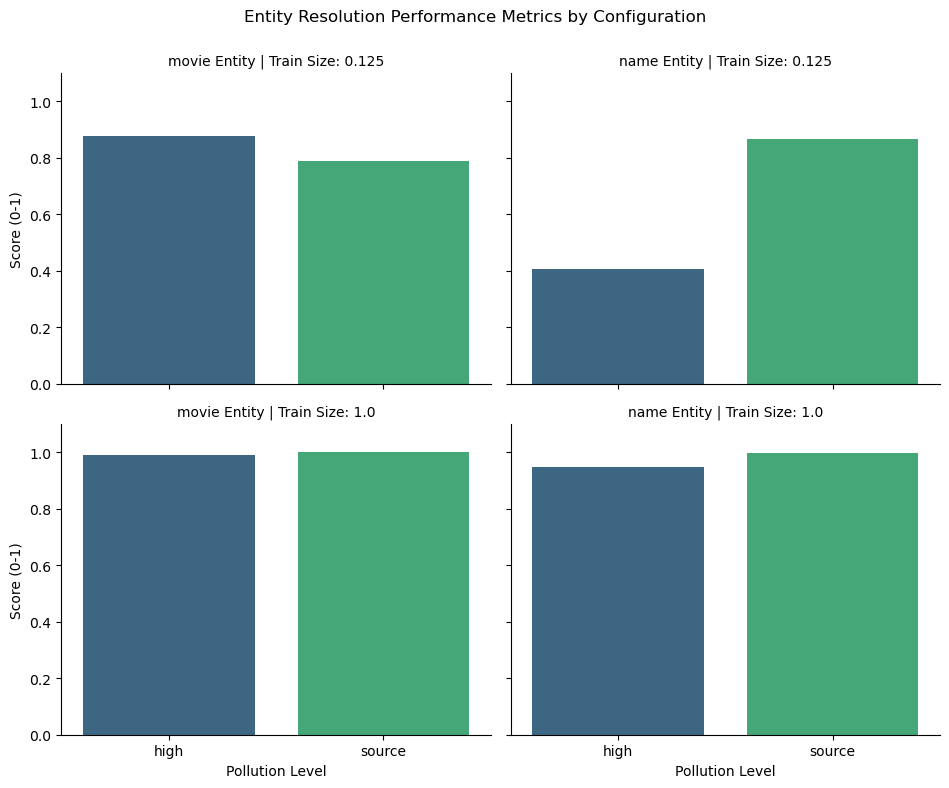

In [20]:

import seaborn as sns
import matplotlib.pyplot as plt

# 2. Reshape the dataframe to "Long Format" for easier plotting
# This combines precision, recall, and f1_score into a single 'Metric' column
# 3. Create the Visualization
# We create a column for 'entity' and rows for 'train_size'
# The x-axis shows the 'pollution' type, and 'Metric' distinguishes the bars
g = sns.catplot(
    data=df_results, 
    kind="bar",
    x="pollution", 
    y="f1_score", 
    # hue="f1_score",
    col="entity", 
    row="train_size",
    palette="viridis",
    height=4, 
    aspect=1.2
)

# 4. Refine the layout
g.set_axis_labels("Pollution Level", "Score (0-1)")
g.set_titles("{col_name} Entity | Train Size: {row_name}")
g.set(ylim=(0, 1.1)) # Metrics are between 0 and 1
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Entity Resolution Performance Metrics by Configuration')

plt.show()

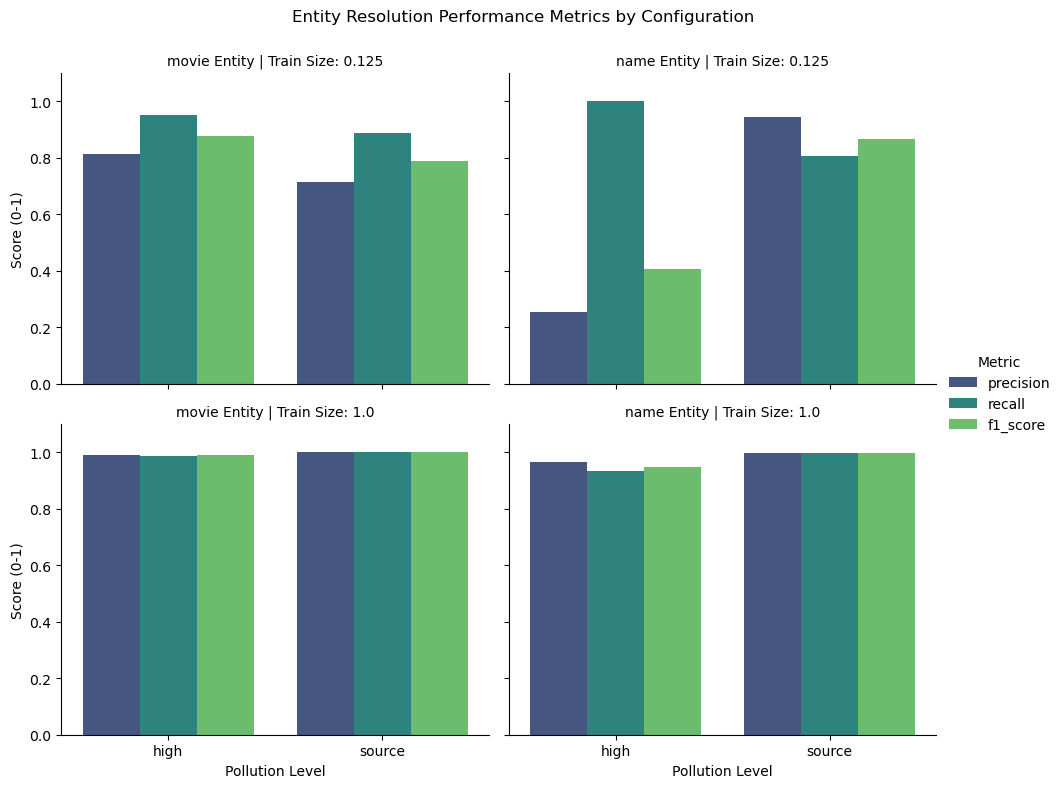

In [15]:

import seaborn as sns
import matplotlib.pyplot as plt

# 2. Reshape the dataframe to "Long Format" for easier plotting
# This combines precision, recall, and f1_score into a single 'Metric' column
df_melted = df_results.melt(
    id_vars=['entity', 'train_size', 'pollution'], 
    value_vars=['precision', 'recall', 'f1_score'],
    var_name='Metric', 
    value_name='Score'
)

# 3. Create the Visualization
# We create a column for 'entity' and rows for 'train_size'
# The x-axis shows the 'pollution' type, and 'Metric' distinguishes the bars
g = sns.catplot(
    data=df_melted, 
    kind="bar",
    x="pollution", 
    y="Score", 
    hue="Metric",
    col="entity", 
    row="train_size",
    palette="viridis",
    height=4, 
    aspect=1.2
)

# 4. Refine the layout
g.set_axis_labels("Pollution Level", "Score (0-1)")
g.set_titles("{col_name} Entity | Train Size: {row_name}")
g.set(ylim=(0, 1.1)) # Metrics are between 0 and 1
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Entity Resolution Performance Metrics by Configuration')

plt.show()

In [9]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connection
conn = sqlite3.connect('../cem_results.db')
update_experiment_view()
i = 8 # Set your desired number of recent runs here

try:
    # 2. Query the last 'i' run_ids from the "runs" table
    # We order by timestamp to ensure we get the truly most recent runs
    id_query = f"""SELECT r.run_id FROM runs r
    WHERE EXISTS (
    SELECT 1 FROM metrics m 
    WHERE m.run_id = r.run_id
    AND m.is_final = 1 
    AND m.testset = 'conv'
    )
    ORDER BY r.timestamp DESC LIMIT {i}"""
    last_run_ids = pd.read_sql_query(id_query, conn)['run_id'].tolist()
    
    if not last_run_ids:
        print("No runs found in the database.")
    else:
        print(last_run_ids)
        # 3. Query experiment_summary for these IDs where is_final=1
        # Using placeholders to prevent SQL injection and handle the list safely
        placeholders = ', '.join(['?'] * len(last_run_ids))
        summary_query = f"""
            SELECT * FROM experiment_summary 
            WHERE run_id IN ({placeholders}) 
            AND testset = 'conv' AND dataset = 'imdb' ORDER BY entity, run_id DESC
        """
        
        # Execute and load into DataFrame
        df_results = pd.read_sql_query(summary_query, conn, params=last_run_ids)
        
        print(f"Successfully retrieved data for {len(last_run_ids)} runs.")
        display(df_results)

finally:
    conn.close()

View 'experiment_summary' has been updated successfully.
['9762087_3_130259_name', '9762105_2_125850_name', '9762087_3_125601_movie', '9762105_2_125323_movie', '9762089_1_123654_name', '9762088_0_123428_name', '9762089_1_122950_movie', '9762088_0_122857_movie']
Successfully retrieved data for 8 runs.


,dataset,entity,train_size,seed,lm,pollution,iteration,testset,f1_score,precision,recall,is_final,run_id
0,imdb,movie,0.125,42,roberta,high,0,conv,0.877,0.815,0.950,0,9762105_2_125323_movie
1,imdb,movie,0.125,42,roberta,high,1,conv,0.877,0.815,0.950,1,9762105_2_125323_movie
2,imdb,movie,1.000,42,roberta,source,0,conv,1.000,1.000,1.000,0,9762089_1_122950_movie
3,imdb,movie,1.000,42,roberta,source,1,conv,1.000,1.000,1.000,1,9762089_1_122950_movie
4,imdb,movie,0.125,42,roberta,source,0,conv,0.790,0.713,0.887,0,9762088_0_122857_movie
5,imdb,movie,0.125,42,roberta,source,1,conv,0.790,0.713,0.887,0,9762088_0_122857_movie
6,imdb,movie,0.125,42,roberta,source,2,conv,0.790,0.713,0.887,1,9762088_0_122857_movie
7,imdb,movie,1.000,42,roberta,high,0,conv,0.989,0.991,0.988,0,9762087_3_125601_movie
8,imdb,movie,1.000,42,roberta,high,1,conv,0.989,0.991,0.987,1,9762087_3_125601_movie
9,imdb,name,0.125,42,roberta,high,0,conv,0.406,0.254,1.000,0,9762105_2_125850_name
